In [ ]:

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [ ]:

df = pd.read_csv("sales_data_sample.csv", encoding="latin1")

In [ ]:

print(df.head())

print(df.info())

print(df.describe())

   ORDERNUMBER  QUANTITYORDERED  PRICEEACH  ORDERLINENUMBER    SALES  \
0        10107               30      95.70                2  2871.00   
1        10121               34      81.35                5  2765.90   
2        10134               41      94.74                2  3884.34   
3        10145               45      83.26                6  3746.70   
4        10159               49     100.00               14  5205.27   

         ORDERDATE   STATUS  QTR_ID  MONTH_ID  YEAR_ID  ...  \
0   2/24/2003 0:00  Shipped       1         2     2003  ...   
1    5/7/2003 0:00  Shipped       2         5     2003  ...   
2    7/1/2003 0:00  Shipped       3         7     2003  ...   
3   8/25/2003 0:00  Shipped       3         8     2003  ...   
4  10/10/2003 0:00  Shipped       4        10     2003  ...   

                    ADDRESSLINE1  ADDRESSLINE2           CITY STATE  \
0        897 Long Airport Avenue           NaN            NYC    NY   
1             59 rue de l'Abbaye           NaN

In [ ]:

print(df.isnull().sum())

ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY           1074
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
dtype: int64


In [ ]:

df = df.dropna()

In [ ]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [ ]:
X = df[['QUANTITYORDERED',
        'PRICEEACH',
        'MSRP',
        'MONTH_ID',
        'YEAR_ID']]

y = df['SALES']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = LinearRegression()

In [ ]:

model.fit(X_train, y_train)


LinearRegression()

In [ ]:
prediction = model.predict(X_test)

In [ ]:
print("R2 Score :", r2_score(y_test, prediction))

print("MAE :", mean_absolute_error(y_test, prediction))

print("MSE :", mean_squared_error(y_test, prediction))

print("RMSE :", mean_squared_error(y_test, prediction) ** 0.5)


R2 Score : 0.7945742727148801
MAE : 619.997591804155
MSE : 804574.3291876449
RMSE : 896.9806738094444


In [ ]:
result = pd.DataFrame({
    "Actual Sales": y_test,
    "Predicted Sales": prediction
})

print(result.head())


      Actual Sales  Predicted Sales
2309       1320.80       987.527804
859        3528.36      3771.122455
2628       4048.00      4694.897544
245        4639.25      4653.929298
1867       3385.90      4044.456020


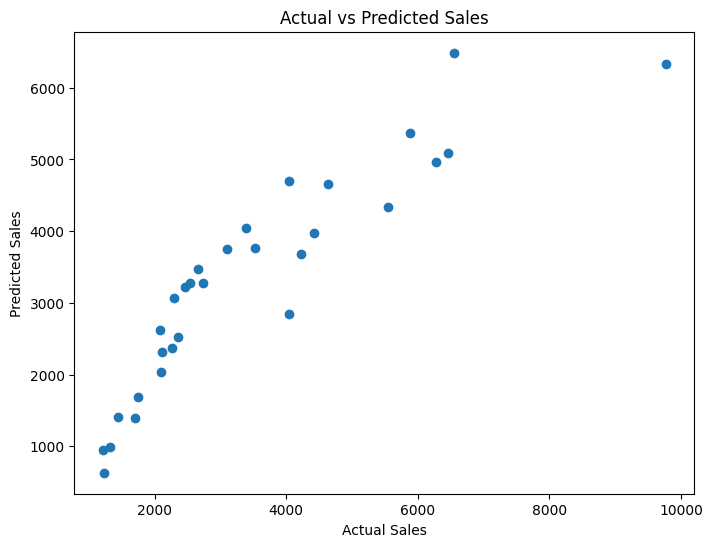

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, prediction)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

In [ ]:
result.to_csv("Sales_Prediction.csv", index=False)

In [ ]:
from google.colab import files
files.download('Sales_Prediction.csv')



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>